## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Housing.csv")
print("First 10 rows:")
df.head(10)

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 545
Number of Columns: 13


In [3]:
print("Target Column: price")
print("\nFeature Columns:")
print(df.columns.drop('price').tolist())

Target Column: price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## Task 2 — Data Cleaning

In [5]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


In [6]:
print(df.dtypes)

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


In [7]:
df = pd.get_dummies(df, drop_first=True,dtype=int)
print(df.head())
print(df.columns.tolist())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   
3  12215000  7500         4          2        2        3             1   
4  11410000  7420         4          1        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   
3              0             1                    0                    1   
4              1             1                    0                    1   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1  

In [8]:
print(df.corr()['price'].sort_values(ascending=False))

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


## Task 3 — Model Building

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1) 
y = df['price']                

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (436, 13)
Testing size: (109, 13)


In [12]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_predicted = lr_model.predict(X_test)

MAE = mean_absolute_error(y_test, lr_predicted)
RMSE = np.sqrt(mean_squared_error(y_test, lr_predicted))
R2 = r2_score(y_test, lr_predicted)

print("Linear Regression Results:")
print("MAE:", round(MAE, 2))
print("RMSE:", round(RMSE, 2))
print("R² Score:", round(R2, 2))

Linear Regression Results:
MAE: 970043.4
RMSE: 1324506.96
R² Score: 0.65


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [15]:
rf_predicted = rf_model.predict(X_test)

MAE_rf = mean_absolute_error(y_test, rf_predicted)
RMSE_rf = np.sqrt(mean_squared_error(y_test, rf_predicted))
R2_rf = r2_score(y_test, rf_predicted)

print("Random Forest Results:")
print("MAE:", round(MAE_rf, 2))
print("RMSE:", round(RMSE_rf, 2))
print("R² Score:", round(R2_rf, 2))

print("\n--- Model Comparison ---")
print("Linear Regression R²:", round(R2, 2))
print("Random Forest R²:", round(R2_rf, 2))

Random Forest Results:
MAE: 1021546.04
RMSE: 1400565.97
R² Score: 0.61

--- Model Comparison ---
Linear Regression R²: 0.65
Random Forest R²: 0.61


## Task 4 — Visualization

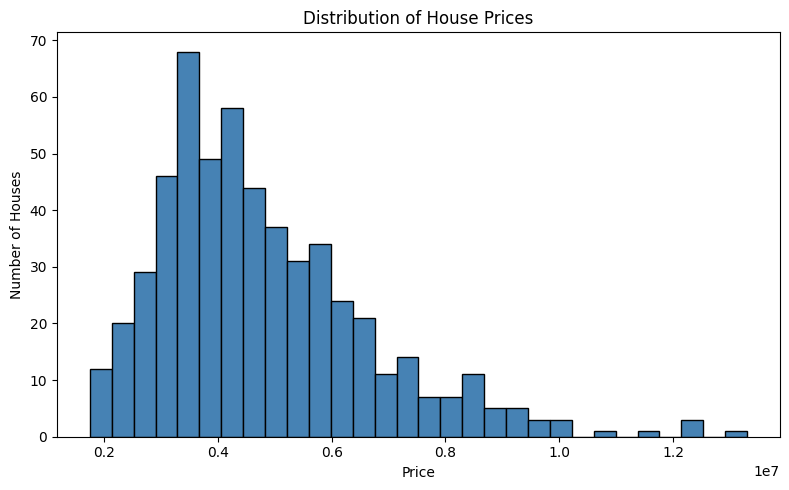

In [16]:
# Chart 1 — Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('chart1_price_distribution.png')
plt.show()

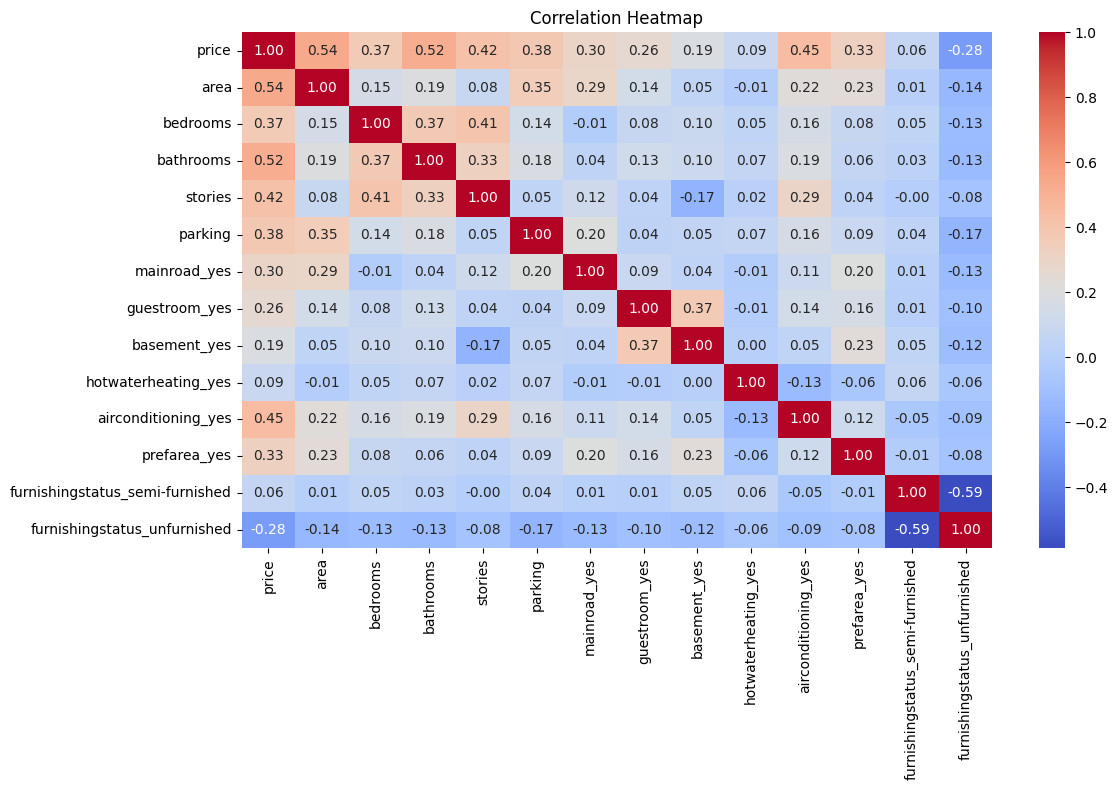

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png')
plt.show()

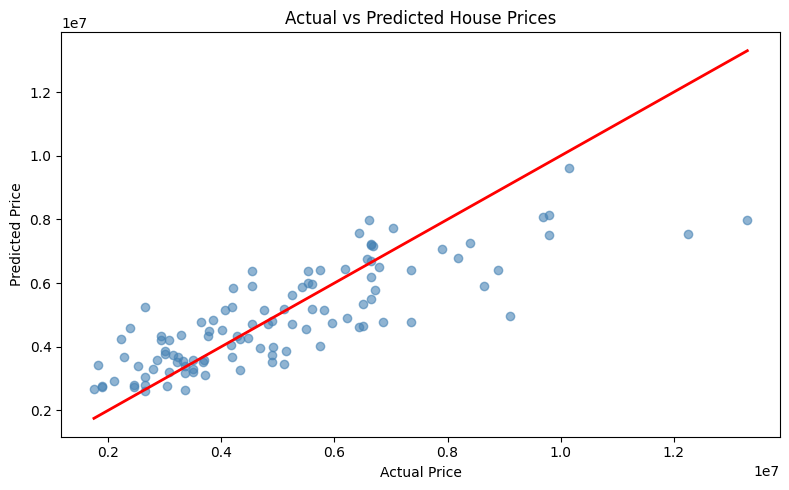

In [18]:
# Chart 3 — Scatter Plot: Actual vs Predicted House Prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_predicted, color='steelblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('chart3_actual_vs_predicted.png')
plt.show()

## Task 5 — Insights & Summary

Based on the analysis of the Housing dataset, the features that influence house price 
the most are area, bathrooms, and air conditioning, as they showed the highest 
correlation with price (0.54, 0.52, and 0.45 respectively). 

The Linear Regression model performed reasonably well with an R² score of 0.65, 
meaning it can correctly explain 65% of the variation in house prices. In simple terms, 
the model can predict house prices with moderate accuracy, being off by around ₹9.7 
lakhs on average.

Surprisingly, Linear Regression outperformed Random Forest (R² 0.65 vs 0.61), which 
is unusual since Random Forest is generally considered more powerful. This is likely 
because the dataset is small (545 rows) and has simple linear relationships.

Recommendation:Real estate businesses should focus on properties with larger area, 
more bathrooms, air conditioning, and furnished interiors, while 
prioritizing locations on main roads and preferred areas, as these 
features together drive the highest market value.